In [213]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [214]:
pd.set_option('display.max_columns', None)
df_eval = pd.read_csv("data/extrait_eval.csv")
df_eval["id_employee"] = df_eval['eval_number'].str.replace('E_', '')
df_eval.drop('eval_number', axis=1, inplace=True)
df_eval.head()


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,id_employee
0,2,3,2,4,1,1,3,Oui,11 %,1
1,3,2,2,2,4,3,4,Non,23 %,2
2,4,2,1,3,2,3,3,Oui,15 %,4
3,4,3,1,3,3,3,3,Oui,11 %,5
4,1,3,1,2,4,3,3,Non,12 %,7


In [215]:
df_sirh = pd.read_csv("data/extrait_sirh.csv")
df_sirh["id_employee"] = df_sirh["id_employee"].astype(str)
df_sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [216]:
df_merge_temp = df_sirh.merge(df_eval, how = "inner", on = ["id_employee"])
df_merge_temp.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %


In [217]:
df_sondage = pd.read_csv("data/extrait_sondage.csv")
df_sondage['id_employee'] = df_sondage['code_sondage'].astype(str)
df_sondage.drop('code_sondage', axis=1, inplace=True)
df_sondage.head()
#print(str(df_sondage['code_sondage']))

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,id_employee
0,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1
1,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7,2
2,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0,4
3,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0,5
4,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2,7


In [218]:
df_merge = df_merge_temp.merge(df_sondage, how = "inner", on = ["id_employee"])

In [219]:
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


<Axes: >

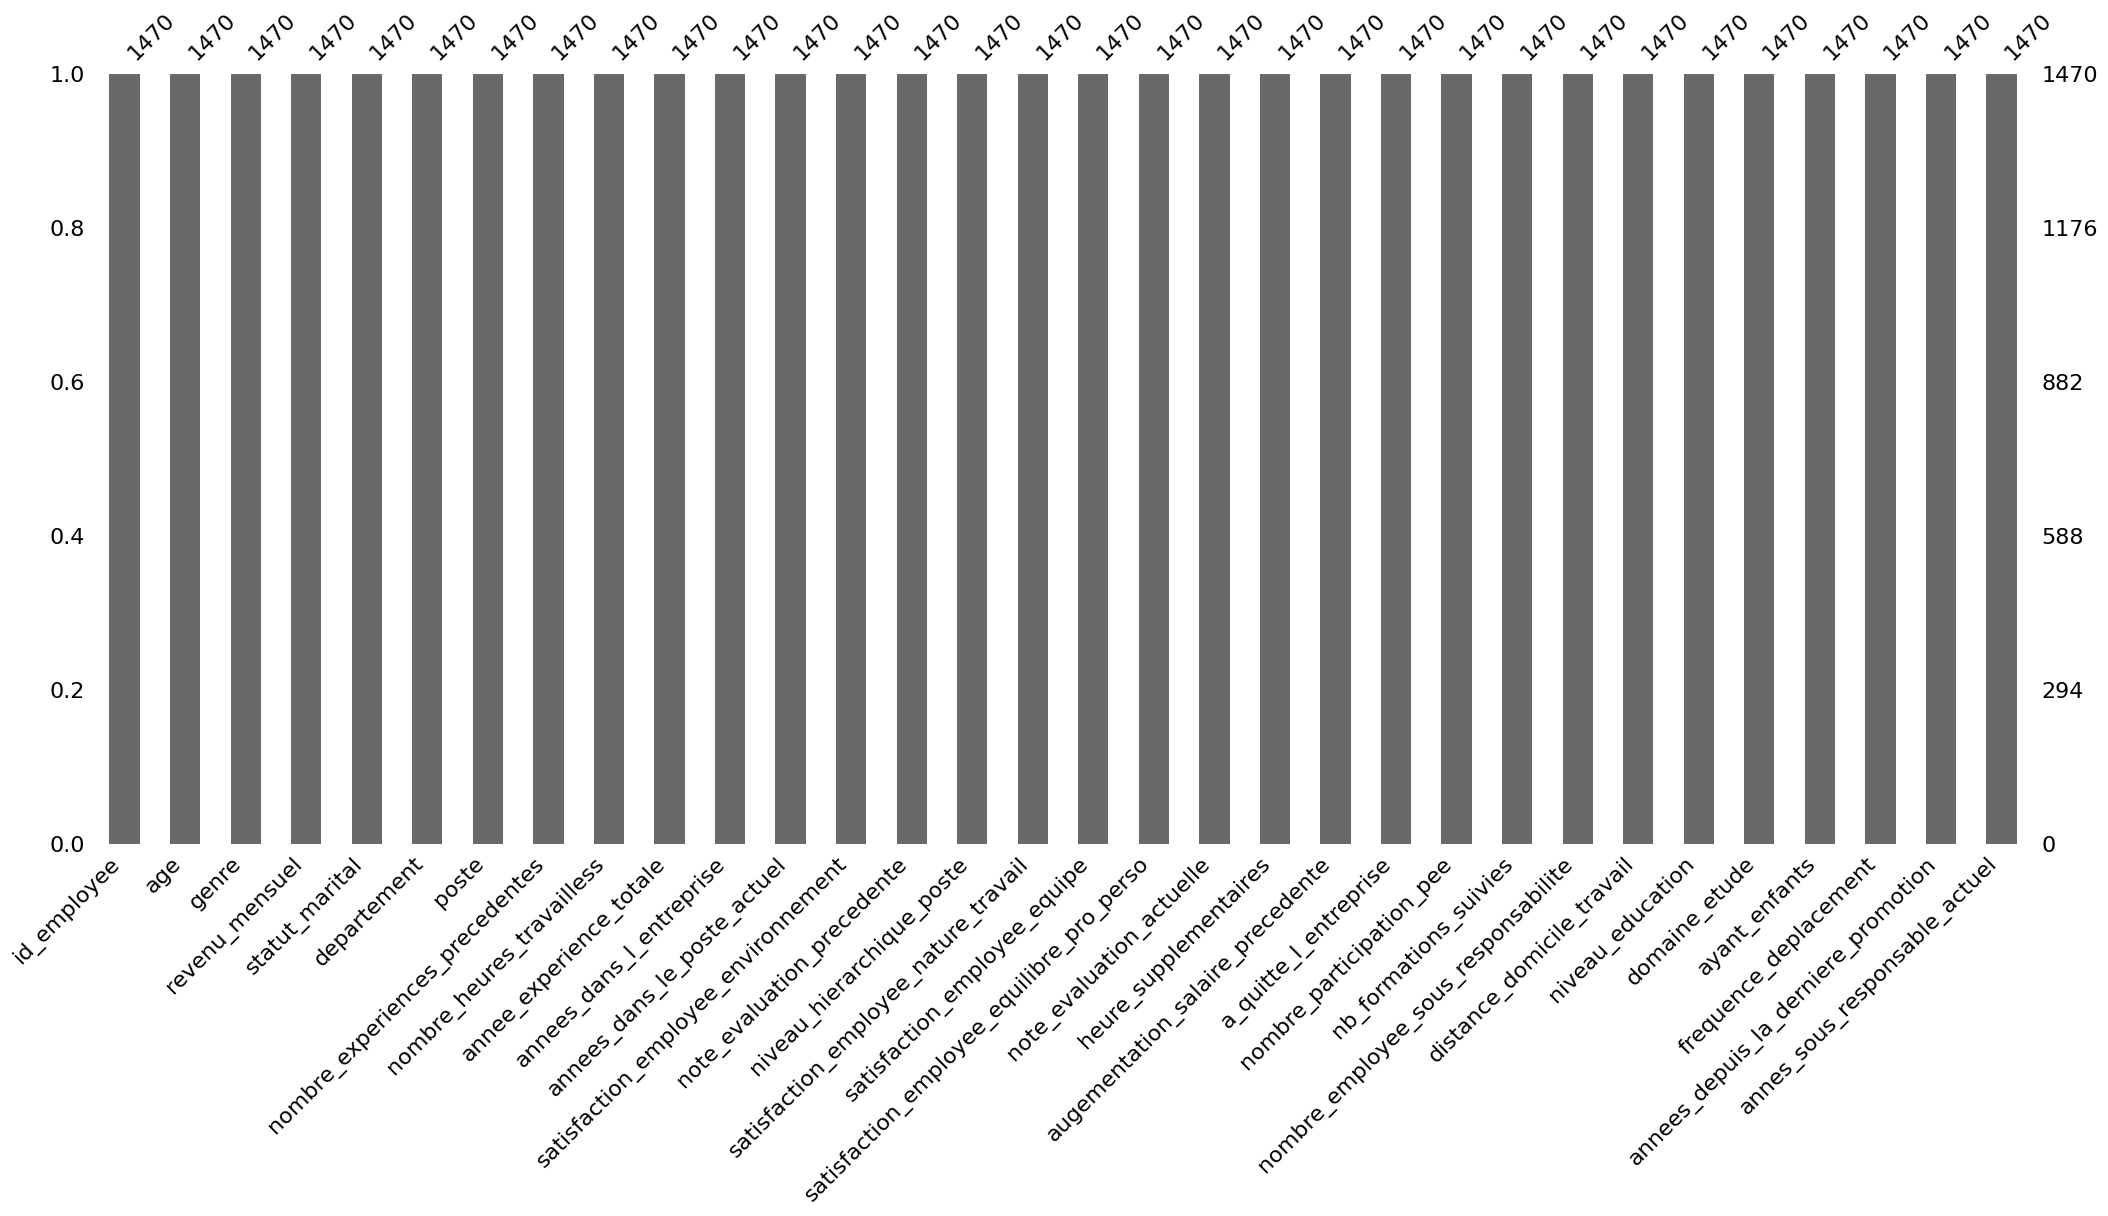

In [220]:
msno.bar(df_merge)

In [221]:
df_merge['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

In [222]:
df_merge['departement'].value_counts()

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

In [223]:
df_merge['poste'].value_counts()

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

In [224]:
df_merge['domaine_etude'].value_counts()

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64

In [225]:
def make_countplot(df, x_axis, y_axis):
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=x_axis, hue=y_axis, data=df)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.legend_.set_title("A quitté l'entreprise \n (Oui : 1 / Non : 0)")

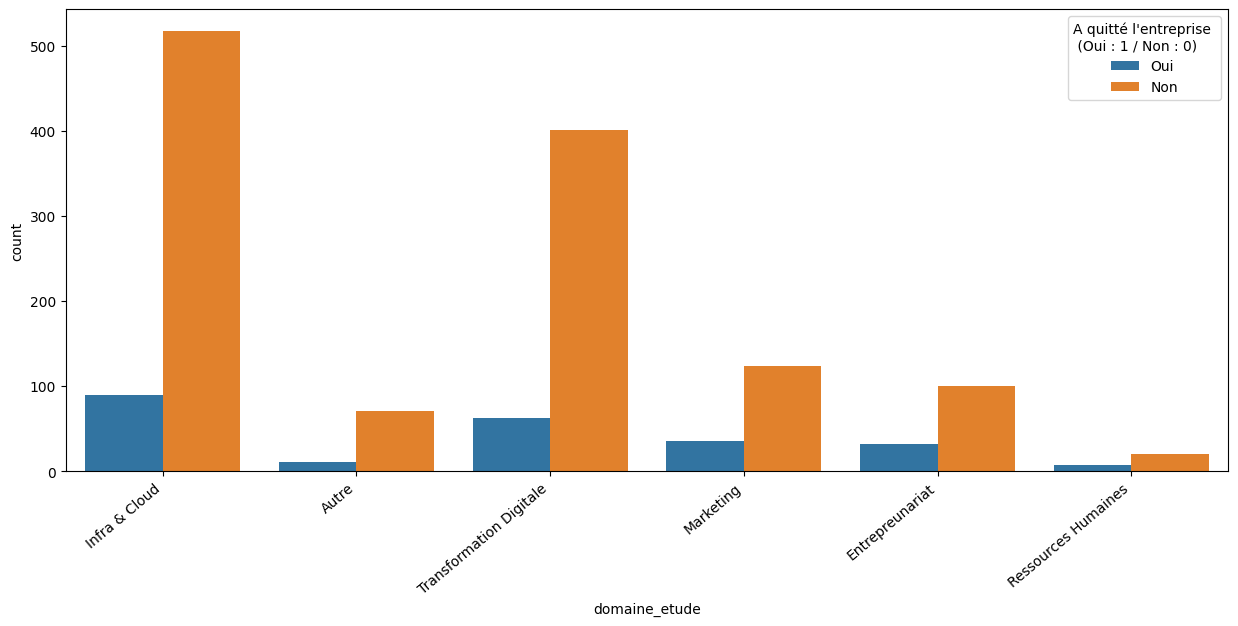

In [226]:
make_countplot(df_merge, "domaine_etude", "a_quitte_l_entreprise")

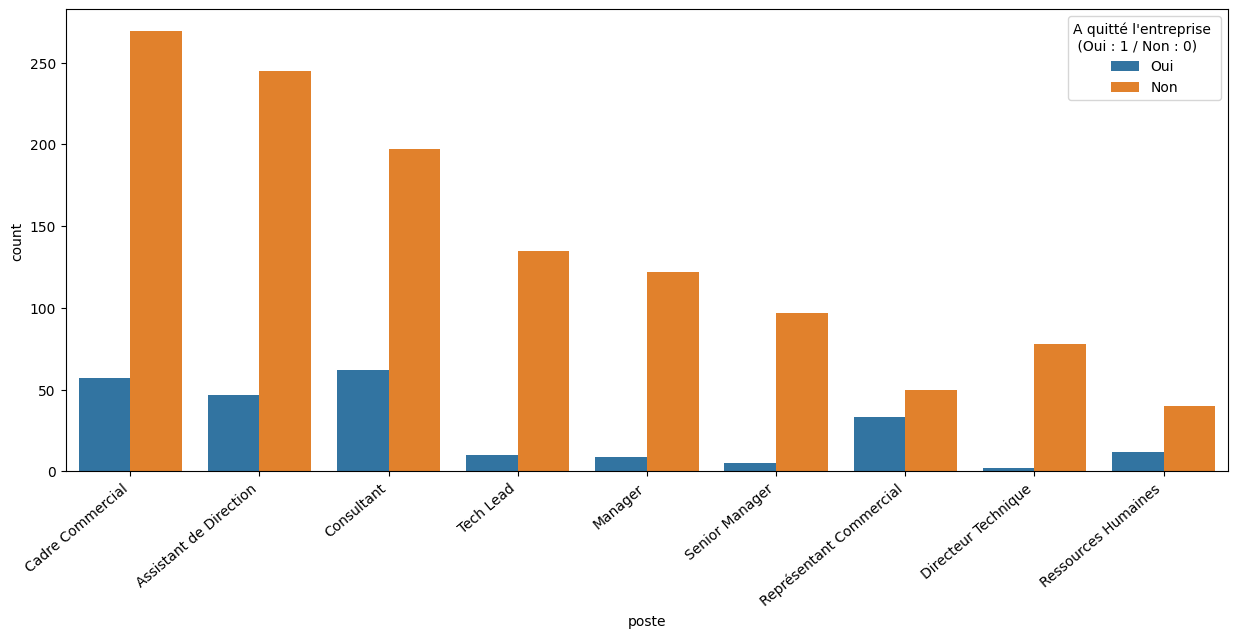

In [227]:
make_countplot(df_merge, "poste", "a_quitte_l_entreprise")

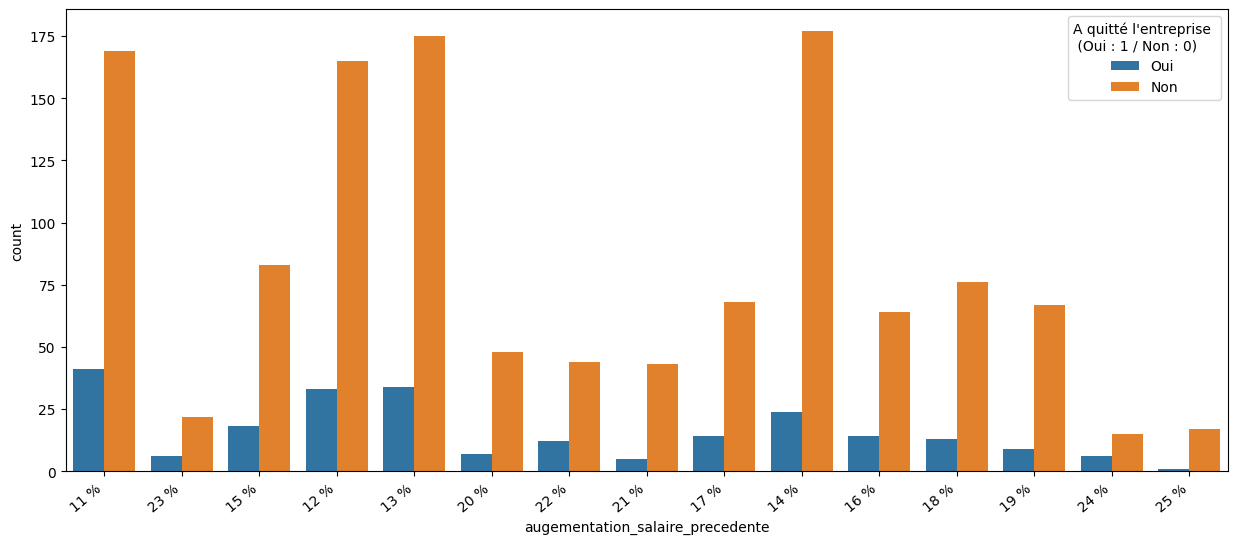

In [228]:
make_countplot(df_merge, "augementation_salaire_precedente", "a_quitte_l_entreprise")

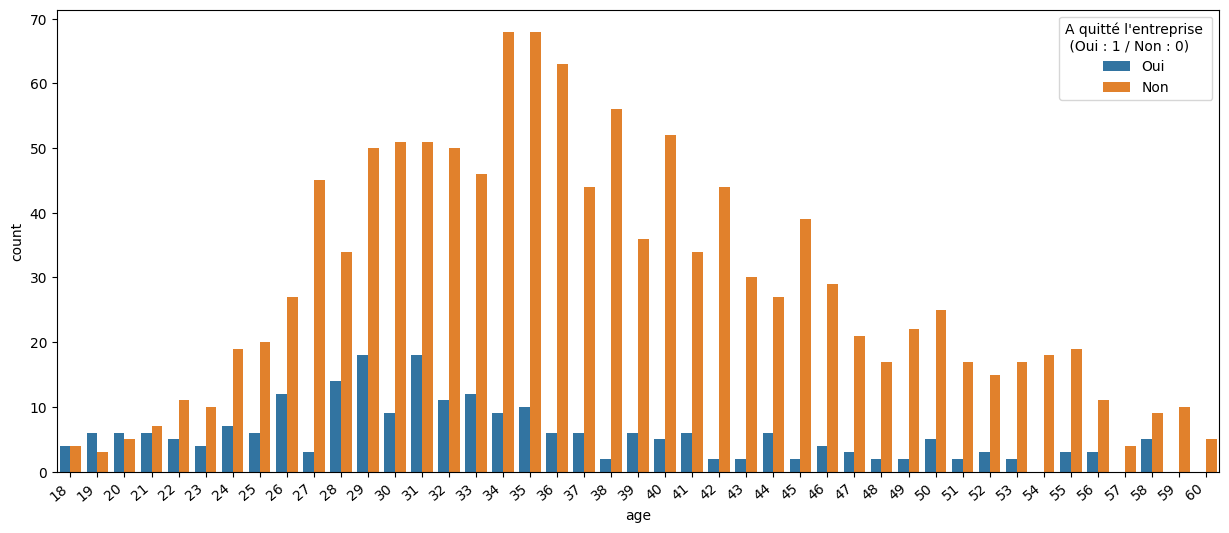

In [229]:
make_countplot(df_merge, "age", "a_quitte_l_entreprise")

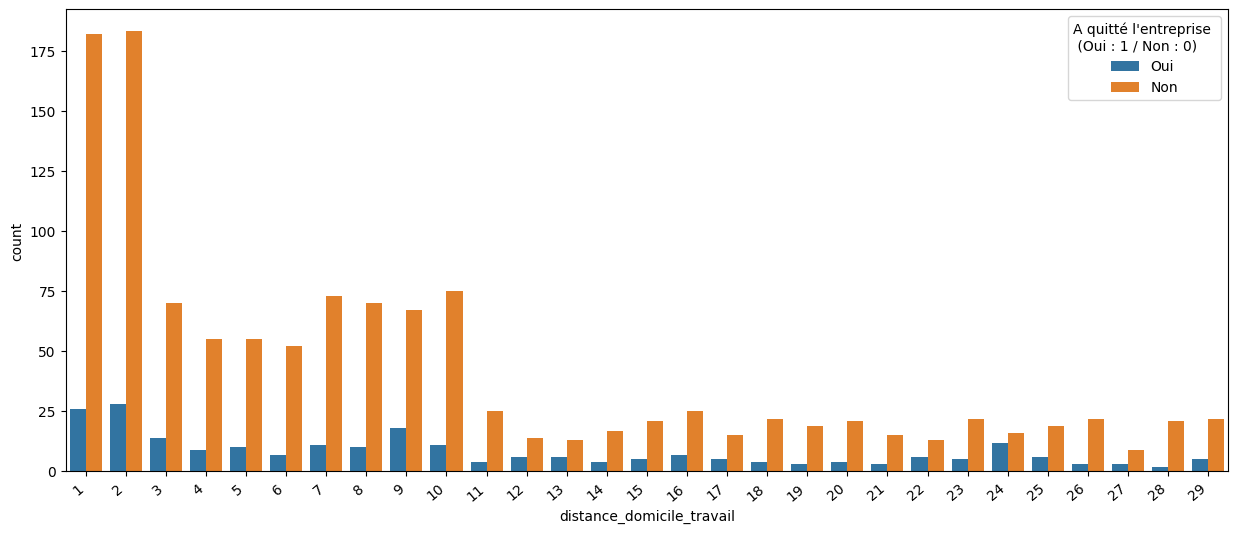

In [230]:
make_countplot(df_merge, "distance_domicile_travail", "a_quitte_l_entreprise")

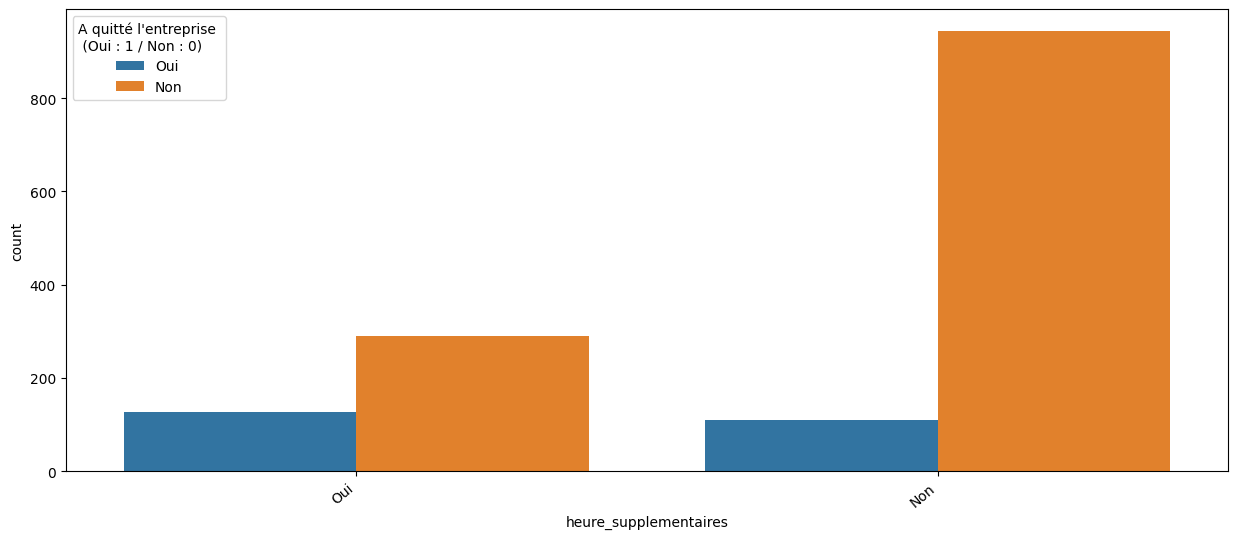

In [231]:
make_countplot(df_merge, "heure_supplementaires", "a_quitte_l_entreprise")

### Feature Engineering

In [232]:
#remplacer les H et F du dataframe par 0 ou 1 
df_merge["genre"] = df_merge["genre"].map({'F': 0, 'M': 1})
df_merge["ayant_enfants"] = df_merge["ayant_enfants"].map({'Y': 0, 'N': 1})
df_merge["heure_supplementaires"] = df_merge["heure_supplementaires"].map({'Oui': 0, 'Non': 1})
df_merge["a_quitte_l_entreprise"] = df_merge["a_quitte_l_entreprise"].map({'Oui': 1, 'Non': 0})
df_merge = df_merge.drop("nombre_heures_travailless", axis=1)
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,0,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,4,2,3,2,4,1,1,3,0,11 %,1,0,0,1,1,2,Infra & Cloud,0,Occasionnel,0,5
1,2,49,1,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,7,3,2,2,2,4,3,4,1,23 %,0,1,3,1,8,1,Infra & Cloud,0,Frequent,1,7
2,4,37,1,2090,Célibataire,Consulting,Consultant,6,7,0,0,4,2,1,3,2,3,3,0,15 %,1,0,3,1,2,2,Autre,0,Occasionnel,0,0
3,5,33,0,2909,Marié(e),Consulting,Assistant de Direction,1,8,8,7,4,3,1,3,3,3,3,0,11 %,0,0,3,1,3,4,Infra & Cloud,0,Frequent,3,0
4,7,27,1,3468,Marié(e),Consulting,Consultant,9,6,2,2,1,3,1,2,4,3,3,1,12 %,0,1,3,1,2,1,Transformation Digitale,0,Occasionnel,2,2


In [233]:
df_merge["id_employee"] = df_merge["id_employee"].astype(int)

In [234]:
df_merge['augementation_salaire_precedente'] = df_merge['augementation_salaire_precedente'].str.rstrip('%').astype(float) / 100

In [235]:
df_merge['augementation_salaire_precedente'].value_counts()

augementation_salaire_precedente
0.11    210
0.13    209
0.14    201
0.12    198
0.15    101
0.18     89
0.17     82
0.16     78
0.19     76
0.22     56
0.20     55
0.21     48
0.23     28
0.24     21
0.25     18
Name: count, dtype: int64

In [236]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   int64  
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   annee_experience_totale                    1470 non-null   int64  
 9   annees_dans_l_entreprise                   1470 non-null   int64  
 10  annees_dans_le_poste_act

In [237]:
#colonne a encodé frequence_deplacement, domaine_etude, poste, departement, statut_marital
def encode_column_with_onehot(df, column_name, max_categories=100):
    # Initialiser le OneHotEncoder
    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return df  # Retourner le DataFrame original sans modification
    encoder = OneHotEncoder(sparse_output=False, drop='first', max_categories=max_categories)  # drop='first' pour éviter la multicolinéarité
    # Appliquer l'encodage sur la colonne spécifiée
    encoded_array = encoder.fit_transform(df[[column_name]])
    # Récupérer les noms des colonnes encodées
    encoded_cols = encoder.get_feature_names_out([column_name])
    # Créer un DataFrame avec les colonnes encodées
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index) # faire en sorte que les colonne soit encodé en object ou int 
    # Supprimer la colonne originale
    df = df.drop(columns=[column_name])
    # Concaténer le DataFrame original avec les colonnes encodées
    df_final = pd.concat([df, df_encoded], axis=1)
    return df_final



In [238]:
df_sans_encode = df

df = encode_column_with_onehot(df_merge, "frequence_deplacement")
df = encode_column_with_onehot(df, "domaine_etude")
df = encode_column_with_onehot(df, "poste")
df = encode_column_with_onehot(df, "departement")
df = encode_column_with_onehot(df, "statut_marital")

### Modélisation

In [239]:
# CODE PREPARATION DES FEATURES
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from imblearn.over_sampling import SMOTE



In [240]:
def modele_classification(df, target_col, modele_type):
    # Séparer les features et la cible
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # Diviser en train et test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # SMOTE
    smote = SMOTE(sampling_strategy='minority', random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # Vérification de l'équilibre après SMOTE
    print("Répartition avant SMOTE :")
    print(y_train.value_counts())

    print("Répartition après SMOTE :")
    print(y_resampled.value_counts())


    # Choisir le modèle
    if modele_type == 'logisticregression':
        model = LogisticRegression(max_iter=5000, class_weight="balanced")
    elif modele_type == 'dummyclassifier':
        model = DummyClassifier(strategy='most_frequent')
    elif modele_type == 'svc':
        model = SVC(probability=True, class_weight='balanced')
    elif modele_type == 'randomforestclassifier':
        model = RandomForestClassifier(random_state=42, class_weight="balanced")
    elif modele_type == 'xgboost':
        model = xgb.XGBClassifier(random_state=42)
    else:
        raise ValueError("Type de modèle non reconnu. Choisissez parmi : 'logisticregression', 'dummyclassifier', 'svc', 'randomforestclassifier', 'xgboost'.")
    
    # Entraîner le modèle -> Données resample ?
    model.fit(X_train, y_train)

    # Entraîner le modèle -> Données resample ?
    #model.fit(X_resampled, y_resampled)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    print(f"===== RÉSULTATS POUR : {modele_type} =====")
    
    # 2. Matrice de confusion (calcul)
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Matrice de confusion (Visualisation avec Seaborn)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=False, annot_kws={"size": 14})
    plt.title(f'Matrice de Confusion - {modele_type}')
    plt.ylabel('Vraie valeur (Actual)')
    plt.xlabel('Prédiction (Predicted)')
    plt.show()
    print("=" * (30 + len(modele_type)))
    
    # 2. Rapport de classification (inclut Précision, Rappel, F1-Score)
    print(f"\nRapport de Classification :")
    report = classification_report(y_test, y_pred)
    print(report)

    
    return y_test, y_pred

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64
===== RÉSULTATS POUR : dummyclassifier =====


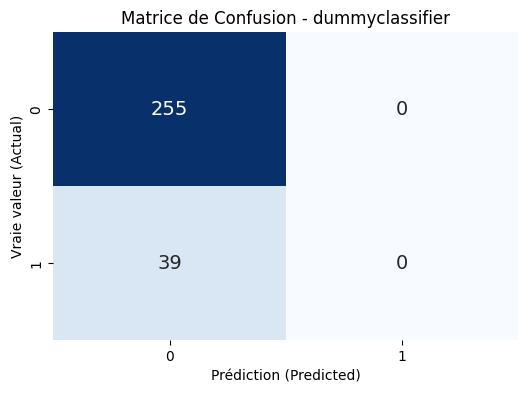


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       255
           1       0.00      0.00      0.00        39

    accuracy                           0.87       294
   macro avg       0.43      0.50      0.46       294
weighted avg       0.75      0.87      0.81       294



In [241]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'dummyclassifier')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64


===== RÉSULTATS POUR : randomforestclassifier =====


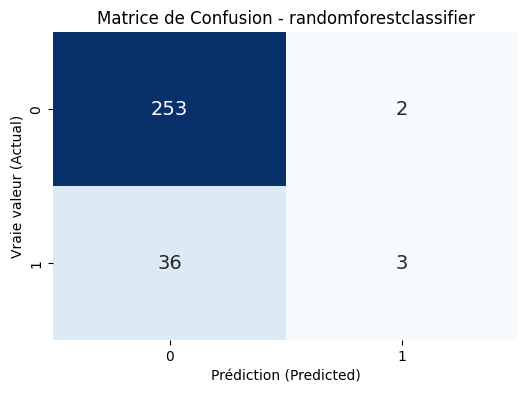


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.60      0.08      0.14        39

    accuracy                           0.87       294
   macro avg       0.74      0.53      0.53       294
weighted avg       0.84      0.87      0.82       294



In [242]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'randomforestclassifier')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64
===== RÉSULTATS POUR : logisticregression =====


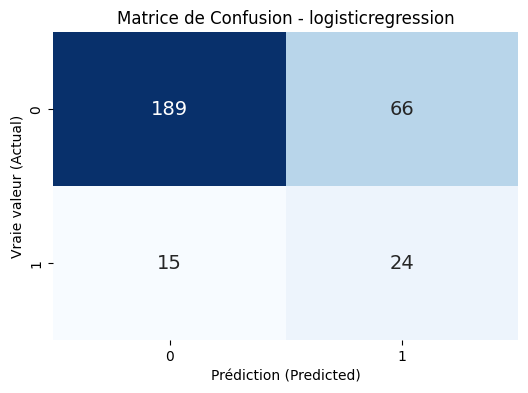


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.93      0.74      0.82       255
           1       0.27      0.62      0.37        39

    accuracy                           0.72       294
   macro avg       0.60      0.68      0.60       294
weighted avg       0.84      0.72      0.76       294



In [243]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'logisticregression')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64
===== RÉSULTATS POUR : svc =====


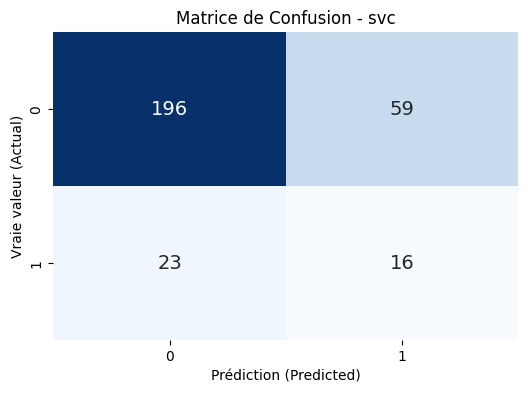


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       255
           1       0.21      0.41      0.28        39

    accuracy                           0.72       294
   macro avg       0.55      0.59      0.55       294
weighted avg       0.80      0.72      0.75       294



In [244]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'svc')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64
===== RÉSULTATS POUR : xgboost =====


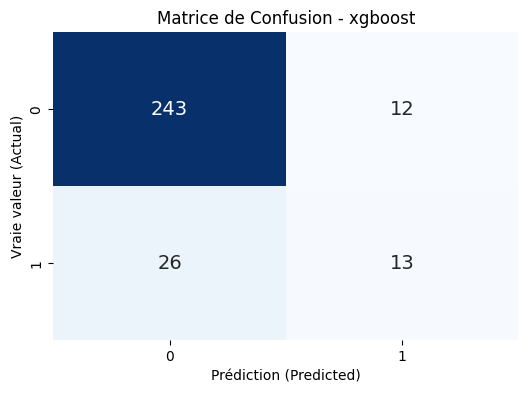


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       255
           1       0.52      0.33      0.41        39

    accuracy                           0.87       294
   macro avg       0.71      0.64      0.67       294
weighted avg       0.85      0.87      0.86       294



In [245]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'xgboost')

In [246]:
import pprint
from sklearn.model_selection import cross_validate

X_rh = df.drop('a_quitte_l_entreprise', axis=1)
y_rh = df['a_quitte_l_entreprise']
X_train, X_test, y_train, y_test = train_test_split(X_rh, y_rh, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(max_depth=5)

scores = cross_validate(model, X_rh, y_rh, cv=5, scoring=('accuracy', 'precision', 'recall', "f1_weighted", "f1_macro" ), return_train_score=True)
pprint.pprint(scores)

#moyenne et ecart type a rajouter 

{'fit_time': array([0.07919431, 0.07130933, 0.09089684, 0.08107853, 0.08157468]),
 'score_time': array([0.01294136, 0.01463985, 0.01508832, 0.01261902, 0.01293325]),
 'test_accuracy': array([0.86734694, 0.8537415 , 0.8537415 , 0.86394558, 0.85034014]),
 'test_f1_macro': array([0.64332597, 0.64697998, 0.69216159, 0.65865552, 0.55139409]),
 'test_f1_weighted': array([0.83369572, 0.82893011, 0.84387981, 0.83873452, 0.8005158 ]),
 'test_precision': array([0.84615385, 0.61904762, 0.55882353, 0.68421053, 0.71428571]),
 'test_recall': array([0.22916667, 0.27083333, 0.40425532, 0.27659574, 0.10638298]),
 'train_accuracy': array([1., 1., 1., 1., 1.]),
 'train_f1_macro': array([1., 1., 1., 1., 1.]),
 'train_f1_weighted': array([1., 1., 1., 1., 1.]),
 'train_precision': array([1., 1., 1., 1., 1.]),
 'train_recall': array([1., 1., 1., 1., 1.])}


In [247]:

import shap
X_rh = df.drop('a_quitte_l_entreprise', axis=1)
y_rh = df['a_quitte_l_entreprise']
X_train, X_test, y_train, y_test = train_test_split(X_rh, y_rh, test_size=0.2, random_state=42)
model = xgb.XGBClassifier()
model.fit(X_train, y_train)
model

df.info()
df.head(1000)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   int64  
 3   revenu_mensuel                             1470 non-null   int64  
 4   nombre_experiences_precedentes             1470 non-null   int64  
 5   annee_experience_totale                    1470 non-null   int64  
 6   annees_dans_l_entreprise                   1470 non-null   int64  
 7   annees_dans_le_poste_actuel                1470 non-null   int64  
 8   satisfaction_employee_environnement        1470 non-null   int64  
 9   note_evaluation_precedente                 1470 non-null   int64  
 10  niveau_hierarchique_post

,id_employee,age,genre,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,ayant_enfants,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,departement_Consulting,departement_Ressources Humaines,statut_marital_Divorcé(e),statut_marital_Marié(e)
0,1,41,0,5993,8,8,6,4,2,3,2,4,1,1,3,0,0.11,1,0,0,1,1,2,0,0,5,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,49,1,5130,1,10,10,7,3,2,2,2,4,3,4,1,0.23,0,1,3,1,8,1,0,1,7,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,4,37,1,2090,6,7,0,0,4,2,1,3,2,3,3,0,0.15,1,0,3,1,2,2,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,5,33,0,2909,1,8,8,7,4,3,1,3,3,3,3,0,0.11,0,0,3,1,3,4,0,3,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,7,27,1,3468,9,6,2,2,1,3,1,2,4,3,3,1,0.12,0,1,3,1,2,1,0,2,2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1402,43,0,4081,1,20,20,7,1,2,2,3,1,1,3,0,0.14,0,0,3,1,6,3,0,1,8,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,1403,27,0,5769,1,6,6,2,4,2,2,4,4,3,3,0,0.11,0,0,3,1,10,3,0,4,4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
997,1405,27,0,2394,1,8,8,2,4,3,1,3,4,3,3,0,0.13,1,0,2,1,17,4,0,7,7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
998,1407,26,1,3904,0,5,4,3,1,2,1,4,4,3,3,1,0.12,0,0,2,1,2,1,0,1,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [248]:
model.predict(X_test)
#df = df.astype(object)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [249]:
y_train

1097    0
727     0
254     0
1175    0
1341    0
       ..
1130    0
1294    0
860     1
1459    0
1126    0
Name: a_quitte_l_entreprise, Length: 1176, dtype: int64

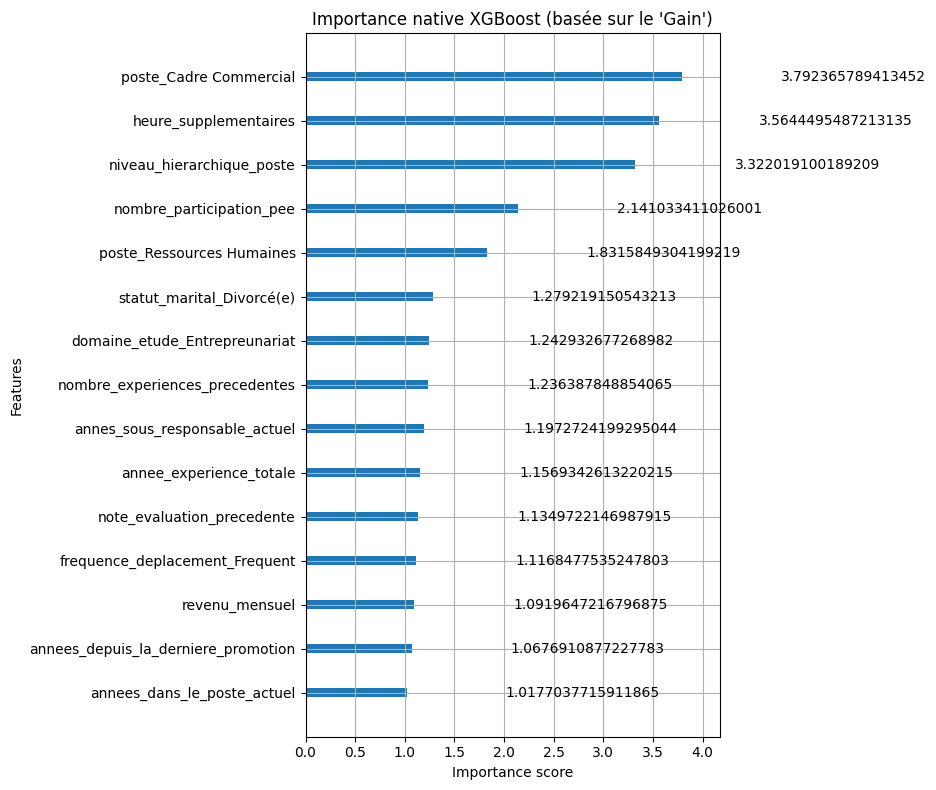

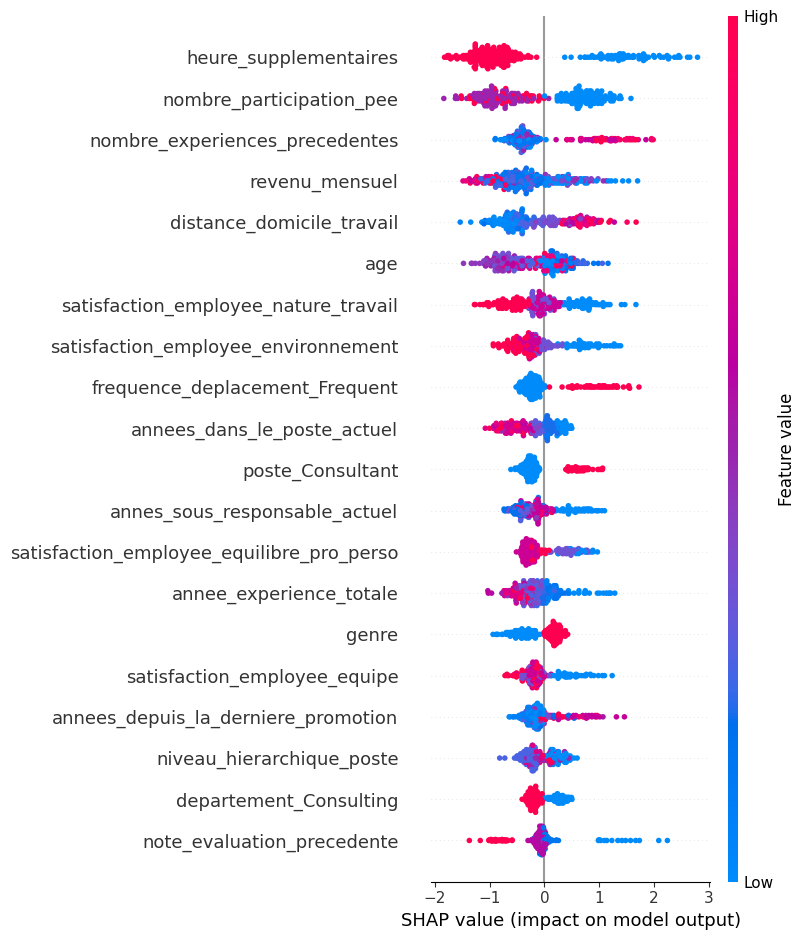

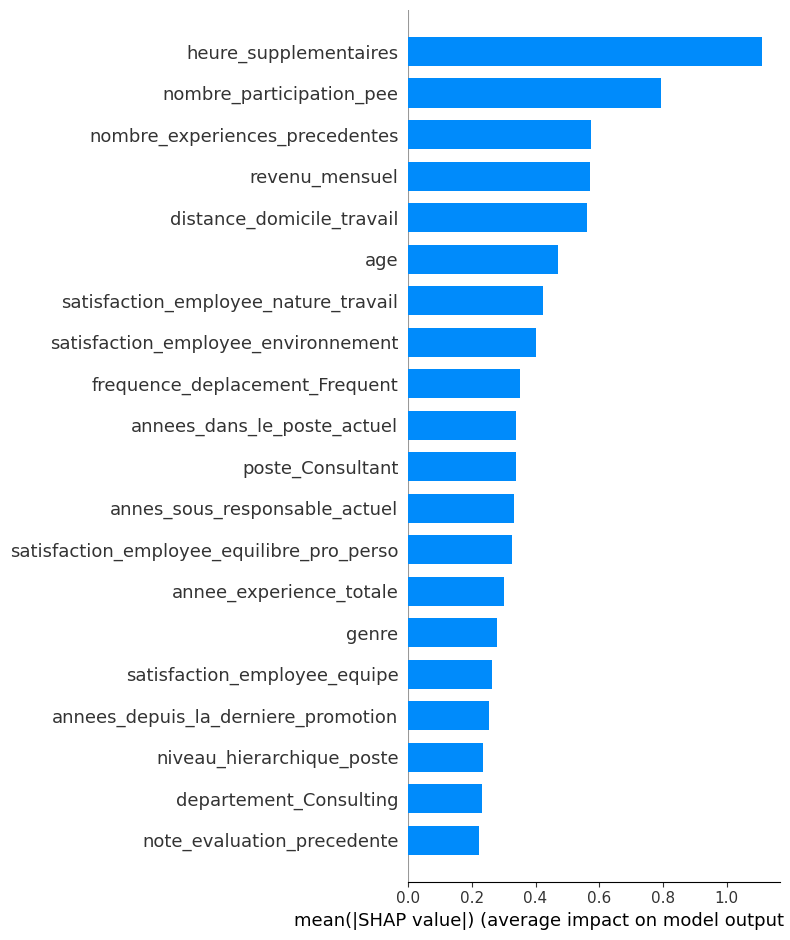

In [250]:
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model, 
                    ax=ax, 
                    importance_type='gain', 
                    max_num_features=15, # Afficher le top 15
                    title="Importance native XGBoost (basée sur le 'Gain')")
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [251]:
# Définir la grille d'hyperparamètres à tester
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [175, 200, 215],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [0.5, 0.6, 0.7]
}

# Configurer la recherche par grille
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=10)

# Lancer la recherche
grid_search.fit(X_train, y_train)

# Meilleur hyperparamètre
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Évaluer le meilleur modèle sur le test
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
#print("Accuracy sur le test :", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5; 1/27] START colsample_bytree=0.5, n_estimators=175, subsample=0.5......
[CV 1/5; 1/27] END colsample_bytree=0.5, n_estimators=175, subsample=0.5;, score=0.860 total time=   0.0s
[CV 2/5; 1/27] START colsample_bytree=0.5, n_estimators=175, subsample=0.5......
[CV 2/5; 1/27] END colsample_bytree=0.5, n_estimators=175, subsample=0.5;, score=0.877 total time=   0.0s
[CV 3/5; 1/27] START colsample_bytree=0.5, n_estimators=175, subsample=0.5......
[CV 3/5; 1/27] END colsample_bytree=0.5, n_estimators=175, subsample=0.5;, score=0.843 total time=   0.0s
[CV 4/5; 1/27] START colsample_bytree=0.5, n_estimators=175, subsample=0.5......
[CV 4/5; 1/27] END colsample_bytree=0.5, n_estimators=175, subsample=0.5;, score=0.838 total time=   0.0s
[CV 5/5; 1/27] START colsample_bytree=0.5, n_estimators=175, subsample=0.5......
[CV 5/5; 1/27] END colsample_bytree=0.5, n_estimators=175, subsample=0.5;, score=0.881 total time=   0.0s
[CV

Meilleurs hyperparamètres : {'colsample_bytree': 1, 'learning_rate': 0.15, 'max_depth': 1, 'n_estimators': 200, 'subsample': 0.6}

In [252]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score



def grid_search_with_cv_metrics(model, param_grid, X, y, scoring='accuracy', cv=5):
    # Créer le GridSearchCV avec validation croisée intégrée
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=False, verbose=1)
    
    # Effectuer la recherche
    grid.fit(X, y)
    
    #cv_results = grid.cv_results_
    # Les scores par fold sont dans 'splitX_test_score' (X étant le fold index)
    # Cependant, pour la plupart des métriques, ce n'est pas directement stocké
    # Donc, pour obtenir les scores par fold, on peut faire une validation croisée manuelle
    # ou utiliser la méthode cross_val_score pour chaque hyperparamètre
    # Ici, on va faire une validation croisée manuelle pour stocker les métriques
    
    # Alternativement, si vous souhaitez uniquement la moyenne et l'écart-type, utilisez cross_val_score
    
    
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    
    # Calculer la moyenne et l'écart-type
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    
    print(f"Métrique moyenne : {mean_score:.3f}")
    print(f"Écart-type : {std_score:.3f}")
    
    return scores, mean_score, std_score

In [253]:
grid_search_with_cv_metrics(model, param_grid, X_rh, y_rh, scoring="f1", cv=5)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Métrique moyenne : 0.401
Écart-type : 0.086


(array([0.35483871, 0.45945946, 0.49411765, 0.44117647, 0.25454545]),
 np.float64(0.4008275482658784),
 np.float64(0.08635068418203905))

# Test Optuna

In [254]:
import optuna
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

model_params_fixed = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss'
    }

In [264]:
def objective(trial):
    
    param = {
        'objective': 'binary:logistic',  # Pour la classification binaire
        'eval_metric': 'logloss',          # Métrique d'évaluation interne
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100), # Nb d'arbres
        'max_depth': trial.suggest_int('max_depth', 3, 10),                     # Profondeur max
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),     # Taux d'apprentissage
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),              # % d'échantillons par arbre
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),  # % de features par arbre
        'gamma': trial.suggest_float('gamma', 0, 5),                            # Réduction de perte minimum
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),                    # Régularisation L1
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),                  # Régularisation L2
        'random_state': 42 # Pour la reproductibilité
    }

    model_xgb = xgb.XGBClassifier(**param) # On passe tous les params d'un coup
    
    model_xgb.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)], # On évalue sur la VALIDATION
                  verbose=False)             # N'affiche pas les logs d'entraînement

    preds = model_xgb.predict(X_test)
    
    # On calcule l'accuracy (précision)
    f1_macro = f1_score(y_test, preds, average='macro')    
    # 2d. Renvoyer le score à Optuna
    # Optuna essaiera de MAXIMISER cette valeur
    return f1_macro

In [ ]:
print("\n--- Démarrage de l'optimisation Optuna ---")

# On crée une "étude". 
# direction="maximize" car nous voulons maximiser le f1.
study = optuna.create_study(direction="maximize")

# On lance l'optimisation !
# Optuna va appeler la fonction 'objective' 50 fois (n_trials=50)
study.optimize(objective, n_trials=150)

# --- ÉTAPE 4 : Afficher les résultats ---

print("\n--- Optimisation terminée ---")
print(f"Nombre d'essais terminés : {len(study.trials)}")

print("Meilleur essai :")
best_trial = study.best_trial

### CHANGEMENT : Le label affiche F1-Score ###
print(f"  Valeur (F1-Score Macro) : {best_trial.value:.4f}")

print("  Meilleurs Hyperparamètres :")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

[I 2025-11-01 22:22:39,024] A new study created in memory with name: no-name-be41599c-bbe0-45f1-985e-b642660bddf6



--- Démarrage de l'optimisation Optuna ---


[I 2025-11-01 22:22:39,378] Trial 0 finished with value: 0.6644736842105263 and parameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.08772966343657441, 'subsample': 0.8395543991015267, 'colsample_bytree': 0.8333296538371311, 'gamma': 2.004740861324612, 'reg_alpha': 0.9305411475344288, 'reg_lambda': 2.8892940269041323}. Best is trial 0 with value: 0.6644736842105263.
[I 2025-11-01 22:22:39,746] Trial 1 finished with value: 0.575485320070592 and parameters: {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.051587606562550306, 'subsample': 0.5064955189475264, 'colsample_bytree': 0.9785758612068898, 'gamma': 3.55260012609733, 'reg_alpha': 2.811866061045035, 'reg_lambda': 1.5802036356115112}. Best is trial 0 with value: 0.6644736842105263.
[I 2025-11-01 22:22:40,199] Trial 2 finished with value: 0.5846840148698884 and parameters: {'n_estimators': 700, 'max_depth': 10, 'learning_rate': 0.28776637630173, 'subsample': 0.9386852112051063, 'colsample_bytree': 0.73224706537


--- Optimisation terminée ---
Nombre d'essais terminés : 150
Meilleur essai :
  Valeur (F1-Score Weighted) : 0.7370
  Meilleurs Hyperparamètres :
    n_estimators: 600
    max_depth: 5
    learning_rate: 0.17755459998476283
    subsample: 0.5535794234472996
    colsample_bytree: 0.827983270987388
    gamma: 1.1146935540801244
    reg_alpha: 2.27203776424836
    reg_lambda: 4.182435357195543


In [266]:
# 1. Récupérer les meilleurs paramètres trouvés
best_params = study.best_params

# 2. On ajoute les paramètres fixes (objective, eval_metric, etc.)
best_params.update(model_params_fixed)
best_params['random_state'] = 42

print("\n--- Entraînement du modèle final optimisé ---")
# C'est ici votre variable 'model'
model = xgb.XGBClassifier(**best_params)

# 3. Entraîner sur TOUTES vos données (X_rh, y_rh)
model.fit(X_rh, y_rh)

print("Modèle final entraîné et prêt à être utilisé !")


--- Entraînement du modèle final optimisé ---
Modèle final entraîné et prêt à être utilisé !


In [267]:
# 1. Faire les prédictions sur le jeu de test
y_pred_test = model.predict(X_test)

# 2. Obtenir le F1-score (le même que celui que vous avez optimisé)
f1_test = f1_score(y_test, y_pred_test, average='weighted')
print(f"\n--- Évaluation Finale sur le Jeu de Test ---")
print(f"Score F1 (Weighted) sur les données de test : {f1_test:.4f}")

# 3. Afficher le rapport complet
# C'est le résultat le plus important.
print("\nRapport de Classification Détaillé (Test) :")
print(classification_report(y_test, y_pred_test))




--- Évaluation Finale sur le Jeu de Test ---
Score F1 (Weighted) sur les données de test : 0.9380

Rapport de Classification Détaillé (Test) :
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       255
           1       0.89      0.64      0.75        39

    accuracy                           0.94       294
   macro avg       0.92      0.81      0.86       294
weighted avg       0.94      0.94      0.94       294



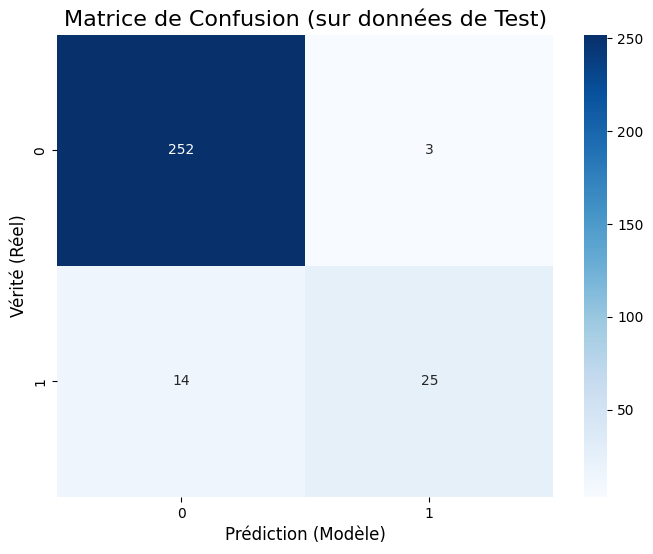

In [268]:
cm = confusion_matrix(y_test, y_pred_test)

# --- ÉTAPE 3 : Obtenir les noms des classes ---
# Pour étiqueter les axes. Si y_rh est un pd.Series et contient 0, 1
# cela donnera ['Classe 0', 'Classe 1']
# Si vous avez déjà les noms (ex: ['Chat', 'Chien']), utilisez-les.
class_names = [f'Classe {i}' for i in np.unique(y_rh)] 
# S'assure que l'ordre est correct
if hasattr(model, 'classes_'):
    class_names = model.classes_


# --- ÉTAPE 4 : Afficher la matrice avec Seaborn ---

plt.figure(figsize=(8, 6)) # Définit la taille de la figure

# C'est la fonction principale de Seaborn
sns.heatmap(cm, 
            annot=True,     # Affiche les chiffres dans les cases
            fmt='d',        # Formate les chiffres en entiers (pas de 1.25e+02)
            cmap='Blues',   # Palette de couleurs (Blues, Greens, Reds...)
            xticklabels=class_names, # Étiquettes pour l'axe X
            yticklabels=class_names) # Étiquettes pour l'axe Y

# Ajout des titres et labels
plt.title('Matrice de Confusion (sur données de Test)', fontsize=16)
plt.ylabel('Vérité (Réel)', fontsize=12)
plt.xlabel('Prédiction (Modèle)', fontsize=12)
plt.show() # Affiche le graphique

In [271]:
# --- Score sur le JEU DE TEST (vous l'avez déjà) ---
y_pred_test = model.predict(X_test)
f1_test = f1_score(y_test, y_pred_test, average='macro')
print(f"Score F1 (Test) : {f1_test:.4f}")

# --- Score sur le JEU D'ENTRAÎNEMENT ---
# (Rappel : votre 'model' final a été entraîné sur X_rh et y_rh)
y_pred_train = model.predict(X_train)
f1_train = f1_score(y_train, y_pred_train, average='macro')
print(f"Score F1 (Train) : {f1_train:.4f}")

print("\n--- Rapport de Classification (Train) ---")
print(classification_report(y_train, y_pred_train))

Score F1 (Test) : 0.8568
Score F1 (Train) : 0.9051

--- Rapport de Classification (Train) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       978
           1       0.98      0.73      0.84       198

    accuracy                           0.95      1176
   macro avg       0.96      0.86      0.91      1176
weighted avg       0.95      0.95      0.95      1176




--- Importance des Features ---
heure_supplementaires                   0.074608
nombre_participation_pee                0.047163
niveau_hierarchique_poste               0.043626
poste_Cadre Commercial                  0.038544
annees_dans_l_entreprise                0.034275
poste_Manager                           0.032962
departement_Consulting                  0.031340
satisfaction_employee_nature_travail    0.030854
age                                     0.030354
satisfaction_employee_environnement     0.029667
dtype: float32


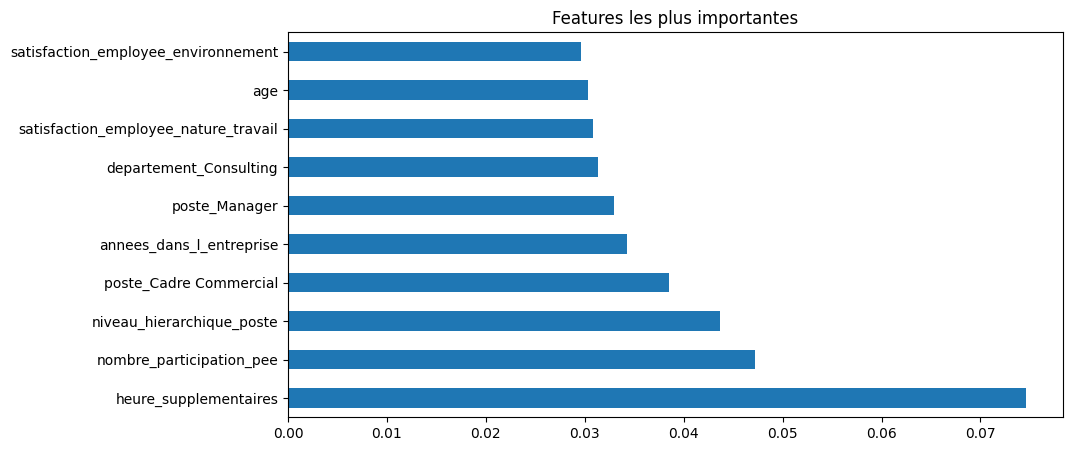

In [272]:
feature_importances = pd.Series(model.feature_importances_, index=X_rh.columns).sort_values(ascending=False)

print("\n--- Importance des Features ---")
print(feature_importances.head(10))

# Visualisation rapide
plt.figure(figsize=(10, 5))
feature_importances.head(10).plot(kind='barh')
plt.title('Features les plus importantes')
plt.show()


Calcul des courbes d'apprentissage (peut prendre un moment)...


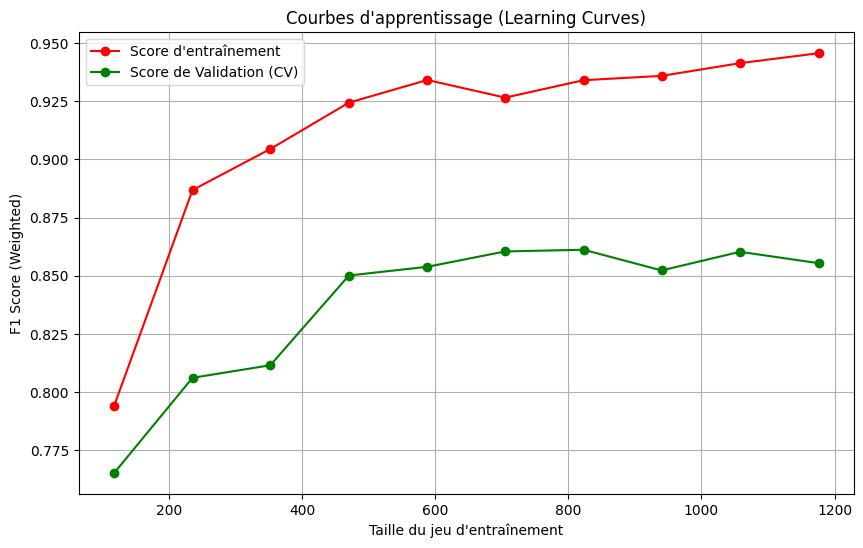

In [273]:
from sklearn.model_selection import learning_curve
print("\nCalcul des courbes d'apprentissage (peut prendre un moment)...")

# Nous utilisons le 'model' final optimisé
train_sizes, train_scores, val_scores = learning_curve(
    model, 
    X_rh,  # On utilise le jeu d'entraînement complet
    y_rh, 
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted', # La métrique qui nous intéresse
    n_jobs=-1, # Utilise tous les processeurs
    train_sizes=np.linspace(0.1, 1.0, 10) # 10 étapes de 10% à 100%
)

# Calculer les moyennes et écarts-types
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# Afficher le graphique
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Score d\'entraînement')
plt.plot(train_sizes, val_scores_mean, 'o-', color='g', label='Score de Validation (CV)')

plt.title('Courbes d\'apprentissage (Learning Curves)')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('F1 Score (Weighted)')
plt.legend(loc='best')
plt.grid()
plt.show()


--- Rapport de Classification Détaillé (Corrigé) ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       255
           1       0.89      0.64      0.75        39

    accuracy                           0.94       294
   macro avg       0.92      0.81      0.86       294
weighted avg       0.94      0.94      0.94       294


--- Matrice de Confusion (Corrigée) ---


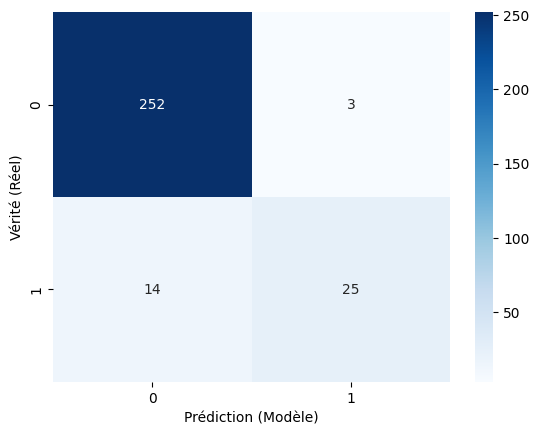

In [274]:
# Imprimez le rapport détaillé
print("\n--- Rapport de Classification Détaillé (Corrigé) ---")
print(classification_report(y_test, y_pred_test))

# Imprimez la matrice de confusion (corrigée)
print("\n--- Matrice de Confusion (Corrigée) ---")
cm = confusion_matrix(y_test, y_pred_test)

# Récupérer les noms de classe depuis la cible (Y_rh)
class_names = sorted(y_rh.unique())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Vérité (Réel)')
plt.xlabel('Prédiction (Modèle)')
plt.show()